# Feature stat tests

This notebook aims at analyzing the feature differences between high and low entropy transcripts using statistical inference tests.

## Section 1: Imports

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Add workflow utilities to path
sys.path.append("/mnt/cbib/LNClassifier/paper/workflow/")
from utils.features import filter_feature_columns, custom_feature_scaling, get_probabilities, remove_constant_features
from utils.parsing import load_tables
from utils.feature_analysis import (
    perform_mann_whitney_tests, perform_f_tests, perform_mutual_info_tests,
    residualize_features, rank_features_by_composite, rank_features_by_score,
    plot_feature_distributions, plot_feature_heatmap, plot_volcano,
    discover_feature_sets, load_feature_set, correlation_and_distance, cluster_features,
    plot_correlation_heatmap, plot_dendrogram
)

# Plotting configuration
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 300
plt.rcParams['pdf.fonttype'] = 42

DATASET = "gencode.v47.common.cdhit.cv"
FIGURE_DIR = f"/mnt/cbib/LNClassifier/paper/results/{DATASET}/features/figures"
os.makedirs(FIGURE_DIR, exist_ok=True)

print("✓ Imports successful")


✓ Imports successful


## Section 2: Configuration

In [ ]:
DATASET_NAME = 'gencode.v47.common.cdhit.cv'
BASEDIR = Path("/mnt/cbib/LNClassifier/paper")

STATISTICAL_METHODS = ['f_test', 'mutual_info', 'mann_whitney']

FDR_METHOD = 'fdr_bh'  # 'fdr_bh' (recommended), 'bonferroni', 'holm', 'fdr_by'
FDR_ALPHA = 0.01

OUTPUT_DIR = BASEDIR / f'results/{DATASET_NAME}/features/simple_analysis/H_pred_th10-90/'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VERBOSE = True

print(f"✓ Configuration loaded")
print(f"  Dataset: {DATASET_NAME}")
print(f"  Output: {OUTPUT_DIR}")
print(f"  Methods: {STATISTICAL_METHODS}")

✓ Configuration loaded
  Dataset: gencode.v47.common.cdhit.cv
  Output: /mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/simple_analysis/H_pred_th10-90
  Methods: ['f_test', 'mutual_info', 'mann_whitney']


## Section 3: Load datasets

In [ ]:
def load_dataset(dataset_name, basedir):
    """Load dataset with predictions and labels."""
    tables = load_tables(dataset_name)
    binary = tables['binary'].set_index('seq_ID')
    pc_ids = binary[binary["real"] == True].index.tolist()
    lnc_ids = binary[binary["real"] == False].index.tolist()
    ids_with_class = pc_ids + lnc_ids
    
    features_df = tables['full_table'].set_index('seq_ID')
    features_df = features_df.loc[ids_with_class]
    probs = get_probabilities(features_df)
    probs = probs.dropna()
    
    labels = pd.DataFrame(index=probs.index)
    labels['coding_class'] = labels.index.isin(pc_ids).astype(int)
    labels['biotype'] = labels['coding_class'].map({1: 'coding', 0: 'lncRNA'})
    
    return {
        'probs': probs,
        'labels': labels,
        'features': features_df.loc[probs.index],
        'binary': binary
    }

def load_additional_features(dataset_name, basedir):
    """Load TE and NBD pipeline features if available."""
    additional = {}
    pipelines = {
        'te_pipeline': 'te_pipeline/results/te_analysis_flexible/features/all_transcripts_te_features.corrected.csv',
        'nbd_pipeline': 'nonb-pipeline/results/gencode.v47/extended_analysis/features_nonb_features.corrected.csv',
        'entropy': f"results/{dataset_name}/uncertainty_analysis/{dataset_name}_uncertainty_analysis.tsv"
    }
    
    for key, rel_path in pipelines.items():
        path = basedir / rel_path
        if path.exists():
            ext = path.suffix
            df = pd.read_csv(path, sep='\t' if ext == '.tsv' else ',', index_col=0)
            additional[key] = df
            if VERBOSE:
                print(f"✓ Loaded {key} ({df.shape[0]} samples × {df.shape[1]} features)")
        else:
            if VERBOSE:
                print(f"⚠ {key} not found at {rel_path}")
    
    return additional

# Load main dataset
dataset = load_dataset(DATASET_NAME, BASEDIR)
dataset.update(load_additional_features(DATASET_NAME, BASEDIR))

probs = dataset['probs']
labels = dataset['labels']
features = dataset['features']
features_to_keep = filter_feature_columns(features)
features = features[features_to_keep]
binary = dataset['binary']

# Load additional features if available
if 'te_pipeline' in dataset:
    te_features = dataset['te_pipeline'].loc[probs.index]
    te_features = te_features.fillna(0)
else:
    te_features = None
    print("⚠ TE features not loaded")

if 'nbd_pipeline' in dataset:
    nbd_features = dataset['nbd_pipeline'].loc[probs.index]
    nbd_features.rename(columns={'motif_types_present': 'n_motif_types'}, inplace=True)
else:
    nbd_features = None
    print("⚠ NBD features not loaded")

if 'entropy' in dataset:
    entropy_df = dataset['entropy'].loc[probs.index]
else:
    entropy_df = None
    print("⚠ Entropy metrics not loaded")

print(f"✓ Data loaded: {len(probs)} transcripts with {len(features.columns)} features")

Extracted 8 probability columns.
Inverting noncoding probabilities...
  - Inverting column: Noncoding_prob_ss_lncDC
✓ Loaded te_pipeline (385659 samples × 173 features)
✓ Loaded nbd_pipeline (385659 samples × 189 features)
✓ Loaded entropy (111652 samples × 18 features)
Identified length columns to exclude: ['Transcript_length_lncDC', 'length_plncpro'] (keeping RNA_size_feelnc for reference)
Total number of columns in features table: 172
Number of kept feature columns: 128
Feature columns: ['kmerScore_1mer_feelnc', 'kmerScore_2mer_feelnc', 'kmerScore_3mer_feelnc', 'kmerScore_6mer_feelnc', 'kmerScore_9mer_feelnc', 'kmerScore_12mer_feelnc', 'ORF_cover_feelnc', 'RNA_size_feelnc', 'ORF_l_cpat', 'Fickett_l_cpat', 'Hexamer_l_cpat', 'ORF_coverage_l_cpat', 'GC_content_lncDC', 'Fickett_score_lncDC', 'ORF_T0_length_lncDC', 'ORF_T1_length_lncDC', 'ORF_T2_length_lncDC', 'ORF_T0_coverage_lncDC', 'ORF_T1_coverage_lncDC', 'ORF_T3_coverage_lncDC', 'Hexamer_score_ORF_T0_lncDC', 'Hexamer_score_ORF_T1_ln

In [ ]:
probs

,coding_score_rnasamba,coding_potential_feelnc,Coding_prob_l_cpat,Noncoding_prob_ss_lncDC,coding_prob_mrnn,P(pcRNA)_lncrnabert,prob_coding_plncpro,Coding.Potential_ss_lncfinder
seq_ID,,,,,,,,
ENST00000000412.8,0.99411,0.958,0.933894,0.999833,0.978755,0.999992,0.714,0.989447
ENST00000002596.6,0.98732,0.954,0.996628,0.996186,0.910619,0.999992,0.915,0.995086
ENST00000002829.8,0.99930,1.000,0.998778,0.998462,0.986240,0.999993,0.846,0.970563
ENST00000005260.9,0.99168,0.980,0.980331,0.999546,0.978858,0.999992,0.887,0.959779
ENST00000005995.8,0.97452,0.994,0.942528,0.999394,0.990389,0.999991,0.637,0.891659
...,...,...,...,...,...,...,...,...
ENST00000715715.1,0.04422,0.010,0.171249,0.000282,0.353438,0.000003,0.044,0.059889
ENST00000715718.1,0.00632,0.022,0.289002,0.000984,0.022870,0.000002,0.020,0.112075
ENST00000715720.1,0.24308,0.016,0.172799,0.004180,0.113424,0.000003,0.041,0.049054


### 3.1 Feature pre-processing
- Combine all feature sets
- Remove constant features
- Transform to numeric
- Separate between categorical and continuous

In [ ]:
original_full = pd.concat([features, te_features, nbd_features], axis=1)
full_feature_set = original_full.copy()
# Since merged df may have duplicate columns:
full_feature_set = full_feature_set.loc[:, ~full_feature_set.columns.duplicated(keep='first')]
# Fill missing values (possible for categorical TE features)
full_feature_set.fillna(0, inplace=True)
# Convert boolean/object columns to numerical (0/1)
full_feature_set = full_feature_set.apply(pd.to_numeric, errors='coerce')

# Keep only numeric features, and report and remove constant features
numeric_cols = full_feature_set.select_dtypes(include=[np.number]).columns
print(f"Full feature set: keeping {len(numeric_cols)} numeric features (out of {full_feature_set.shape[1]} total)")
numeric_df = full_feature_set[numeric_cols]
nunique = numeric_df.nunique()
constant_features = nunique[nunique <= 1].index.tolist()
if constant_features:
    print(f"Full feature set: Removing {len(constant_features)} constant features")
    print(f"  Constant features: {constant_features}")
    full_feature_set = numeric_df.drop(columns=constant_features)

Full feature set: keeping 487 numeric features (out of 487 total)
Full feature set: Removing 27 constant features
  Constant features: ['all_numhits_plncpro', 'all_HitScore_plncpro', 'all_Frame_Entropy_plncpro', 'all_Bitscore_plncpro', 'te_has_ervk', 'te_ervk_count', 'te_has_ervl', 'te_ervl_count', 'te_has_ervl-malr', 'te_ervl-malr_count', 'te_has_erv1', 'te_erv1_count', 'pseudo_unique_families', 'te_ervk_count_per_kb', 'te_ervl_count_per_kb', 'te_ervl-malr_count_per_kb', 'te_erv1_count_per_kb', 'transcript_type', 'coding_class', 'apr_transcript_id', 'dr_transcript_id', 'gq_transcript_id', 'ir_transcript_id', 'mr_transcript_id', 'str_transcript_id', 'tri_transcript_id', 'z_transcript_id']


In [ ]:
# Separate scalar (numeric) from categorical features
categorical_features = []
scalar_features = []

cat_substrings = ['_has_', '_present']
cat_col_names = ["ORF_frame_l_cpat"]

cat_cols = [col for col in full_feature_set.columns if any(sub in col for sub in cat_substrings) or col in cat_col_names]
# Remaining are scalar (numeric)
scalar_cols = full_feature_set.columns.difference(cat_cols).tolist()

if cat_cols:
    categorical_features = full_feature_set[cat_cols]
if scalar_cols:
    scalar_features = full_feature_set[scalar_cols]

if VERBOSE:
    print(f"  Categorical features: {len(cat_cols)} (containing substrings {cat_substrings} or in {cat_col_names})")
    print(f"  Scalar features: {len(scalar_cols)}")

  Categorical features: 24 (containing substrings ['_has_', '_present'] or in ['ORF_frame_l_cpat'])
  Scalar features: 436


### 3.2 Obtain entropy groups

In [ ]:
entropy_df

,H_pred,H_exp,I_bald,mean_prob,variance,std,range,ensemble_prob,ensemble_pred,true_label,biotype,n_strong_lnc,n_strong_coding,n_moderate,extreme_disagreement,extreme_agreement,majority_agreement,percentile_group
seq_ID,,,,,,,,,,,,,,,,,,
ENST00000000412.8,0.303135,0.219188,0.083948,0.946004,0.009315,0.096513,0.285992,0.946004,1,1,coding,0,7,1,False,True,True,Middle
ENST00000002596.6,0.197621,0.166846,0.030775,0.969354,0.001432,0.037848,0.089373,0.969354,1,1,coding,0,8,0,False,True,True,Low H_pred / Low I_bald
ENST00000002829.8,0.169100,0.119347,0.049753,0.974917,0.002820,0.053108,0.154000,0.974917,1,1,coding,0,8,0,False,True,True,Low H_pred / Low I_bald
ENST00000005260.9,0.183502,0.157039,0.026462,0.972148,0.001355,0.036809,0.112992,0.972148,1,1,coding,0,8,0,False,True,True,Low H_pred / Low I_bald
ENST00000005995.8,0.370811,0.258398,0.112413,0.928685,0.015272,0.123578,0.362991,0.928685,1,1,coding,0,7,1,False,True,True,Middle
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENST00000715715.1,0.420876,0.316363,0.104513,0.085385,0.014785,0.121595,0.353435,0.085385,0,0,lncRNA,7,0,1,False,True,True,Middle
ENST00000715718.1,0.324088,0.236419,0.087669,0.059157,0.009934,0.099667,0.289000,0.059157,0,0,lncRNA,7,0,1,False,True,True,Middle
ENST00000715720.1,0.401976,0.332629,0.069348,0.079942,0.007864,0.088678,0.243077,0.079942,0,0,lncRNA,7,0,1,False,True,True,Middle


In [ ]:
# Simple group definition based on H_pred percentiles
high_perc_th = 0.9
high_th_pred = np.percentile(entropy_df['H_pred'], high_perc_th * 100)
high_tr_bald =np.percentile(entropy_df['I_bald'], high_perc_th * 100)
high_mask = (entropy_df['H_pred'] >= high_th_pred) & (entropy_df['I_bald'] >= high_tr_bald)


high_df = entropy_df[high_mask]

grp1 = high_df[high_df["true_label"] == 0].index
grp2 = high_df[high_df["true_label"] == 1].index

## 3.3 Remove any features that became constant only within entropy groups

In [ ]:
scalar_features = remove_constant_features(scalar_features.loc[grp1.union(grp2)], name="Scalar features in entropy groups")
categorical_features = remove_constant_features(categorical_features.loc[grp1.union(grp2)], name="Categorical features in entropy groups")

Scalar features in entropy groups: Removing 7 constant features
  Constant features: ['pseudo_rrna_count', 'pseudo_rrna_count_per_kb', 'pseudo_sum_fragmented', 'te_ple_count', 'te_ple_count_per_kb', 'te_rc_count', 'te_rc_count_per_kb']
Categorical features in entropy groups: Removing 3 constant features
  Constant features: ['te_has_ple', 'te_has_rc', 'pseudo_has_rrna']


## Section 4: Statistical tests

### 4.1 Due diligence on test choices

In [ ]:
from scipy.stats import shapiro, levene
import warnings

warnings.filterwarnings('ignore')

# Test normality for all scalar features using Shapiro-Wilk test
normality_results = []

for col in scalar_features.columns:
    d1_vals = scalar_features.loc[grp1, col].dropna()
    d2_vals = scalar_features.loc[grp2, col].dropna()
    
    # Shapiro-Wilk test for normality (H0: data is normally distributed)
    stat_d1, p_d1 = shapiro(d1_vals)
    stat_d2, p_d2 = shapiro(d2_vals)
    
    # Levene's test for equality of variances (H0: variances are equal)
    stat_levene, p_levene = levene(d1_vals, d2_vals)
    
    normality_results.append({
        'feature': col,
        'normality_low_p': p_d1,
        'normality_high_p': p_d2,
        'levene_p': p_levene,
        'normal_both': (p_d1 > 0.05) and (p_d2 > 0.05),
        'equal_var': p_levene > 0.05
    })

normality_df = pd.DataFrame(normality_results).set_index('feature')

# Summary
n_normal_both = normality_df['normal_both'].sum()
n_equal_var = normality_df['equal_var'].sum()

print(f"✓ Normality tests completed for {len(normality_df)} scalar features")
print(f"\nSummary:")
print(f"  Features with BOTH groups normally distributed (p > 0.05): {n_normal_both} / {len(normality_df)} ({100*n_normal_both/len(normality_df):.1f}%)")
print(f"  Features with equal variances (Levene p > 0.05): {n_equal_var} / {len(normality_df)} ({100*n_equal_var/len(normality_df):.1f}%)")
print(f"\n  → Mann-Whitney U test (non-parametric) is appropriate for most features")
print(f"  → T-test could be used only for {n_normal_both} features with both normal distributions")
print(f"\nTop features with worst normality (lowest p-values):")
normality_df[['normality_low_p', 'normality_high_p', 'levene_p', 'normal_both', 'equal_var']].sort_values('normality_low_p').head(20)

✓ Normality tests completed for 429 scalar features

Summary:
  Features with BOTH groups normally distributed (p > 0.05): 0 / 429 (0.0%)
  Features with equal variances (Levene p > 0.05): 163 / 429 (38.0%)

  → Mann-Whitney U test (non-parametric) is appropriate for most features
  → T-test could be used only for 0 features with both normal distributions

Top features with worst normality (lowest p-values):


,normality_low_p,normality_high_p,levene_p,normal_both,equal_var
feature,,,,,
pseudo_mean_perc_ins,1.152433e-50,1.000000e+00,0.023716,False,False
pseudo_min_perc_ins,1.152433e-50,1.000000e+00,0.023716,False,False
pseudo_max_perc_ins,1.152433e-50,1.000000e+00,0.023716,False,False
pseudo_min_perc_del,1.372261e-50,1.583815e-82,0.028930,False,False
pseudo_max_perc_del,1.372261e-50,1.583815e-82,0.028930,False,False
pseudo_mean_perc_del,1.372261e-50,1.583815e-82,0.028930,False,False
unknown_count,1.503687e-50,2.519388e-82,0.005595,False,False
te_srprna_count_per_kb,1.516848e-50,1.383469e-82,0.491589,False,True
pseudogene_gaps_max,1.559048e-50,2.190449e-82,0.986350,False,True


### 4.2 Tests

In [ ]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import mannwhitneyu, rankdata, chisquare
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from statsmodels.stats.multitest import multipletests

In [ ]:
def vargha_delaney_A(d1, d2):
    """
    Vargha-Delaney A statistic: P(X1 > X2) for unequal sample sizes.

    Parameters:
    -----------
    d1, d2 : array-like
        Two samples to compare

    Returns:
    --------
    float: Probability in range [0, 1]
    """
    n1, n2 = len(d1), len(d2)
    U = mannwhitneyu(d1, d2, method="auto").statistic
    return U / (n1 * n2)

In [ ]:
d1 = scalar_features.loc[grp1,]
d2 = scalar_features.loc[grp2]

stat, pval = mannwhitneyu(d2, d1, alternative="two-sided")
vda = vargha_delaney_A(d2.values, d1.values)
interpretation = [f"{val:.3f} probability of being higher in lncRNA group" for val in vda]

mannu_df = pd.DataFrame({
    'statistic': stat,
    'p_value': pval,
    'vda': vda,
    'interpretation': interpretation},
    index=d1.columns)


In [ ]:
n_sign = (mannu_df['p_value'] < 0.05).sum()
print(f"Number of features with significant difference between lncRNA and Coding groups (Mann-Whitney U test, p < 0.05): {n_sign} / {len(mannu_df)}")
print(f"")
mannu_df.sort_values('vda', ascending=False)

Number of features with significant difference between lncRNA and Coding groups (Mann-Whitney U test, p < 0.05): 304 / 429



,statistic,p_value,vda,interpretation
kmerScore_12mer_feelnc,1557693.0,8.285119e-80,0.728038,0.728 probability of being higher in lncRNA group
RCB_T0_lncDC,1516738.5,2.842474e-67,0.708897,0.709 probability of being higher in lncRNA group
MFE_lncfinder,1495622.0,3.095218e-61,0.699027,0.699 probability of being higher in lncRNA group
ir_gaps_mean_pct,1487738.0,4.676682e-59,0.695342,0.695 probability of being higher in lncRNA group
ir_mean_length_pct,1464256.5,8.356297e-53,0.684368,0.684 probability of being higher in lncRNA group
...,...,...,...,...
Hexamer_score_ORF_T0_lncDC,581441.0,5.983294e-80,0.271755,0.272 probability of being higher in lncRNA group
ORF_T2_MW_lncDC,572283.0,6.636360e-83,0.267475,0.267 probability of being higher in lncRNA group
ORF_T2_length_lncDC,568071.0,2.748708e-84,0.265506,0.266 probability of being higher in lncRNA group
ORF_T0_MW_lncDC,566322.5,7.398199e-85,0.264689,0.265 probability of being higher in lncRNA group


In [ ]:
from scipy.stats import chi2_contingency

c1 = categorical_features.loc[grp1,]
c2 = categorical_features.loc[grp2]
# Perform chi-squared test for each categorical feature
chi2_results = []
for col in c1.columns:
    contingency_table = pd.crosstab(
        pd.concat([c1[col], c2[col]]),
        pd.concat([pd.Series([0]*len(c1), index=c1.index), pd.Series([1]*len(c2), index=c2.index)])
    )

    if col == 'lctr_has_simple_repeat':
        print(f"Contingency table for {col}:")
        print(contingency_table)
    
    chi2_stat, chi2_pval, _, _ = chi2_contingency(contingency_table)

    # Calculate Cramér's V for categorical features
    n = len(c1) + len(c2)
    cramers_v = np.sqrt(chi2_stat / (n * (min(contingency_table.shape) - 1))) if min(contingency_table.shape) > 1 else 0

    # Phi
    phi = np.sqrt(chi2_stat / n) if n > 0 else 0

    # Calculate contingency table odds ratio if it's 2x2
    if contingency_table.shape == (2, 2):
        a = contingency_table.iloc[0, 0]  # No & Low Entropy
        b = contingency_table.iloc[0, 1]  # No & High Entropy
        c = contingency_table.iloc[1, 0]  # Yes & Low Entropy
        d = contingency_table.iloc[1, 1]  # Yes & High Entropy

        # If any of the counts are zero, we can add 0.5 to all cells (Haldane-Anscombe correction) to avoid infinite odds ratios
        if (b * c) == 0 or (a * d) == 0:
            a += 0.5
            b += 0.5
            c += 0.5
            d += 0.5
            print(f"Applied Haldane-Anscombe correction for {col} due to zero counts")

        odds_ratio = (a * d) / (b * c)
        direction = 'positive' if odds_ratio > 1 else 'negative'
    else:
        odds_ratio = np.nan  # Not defined for non-2x2 tables
        direction = 'undef'
    
    interpretation = f"Odds of being protein-coding while having the feature are {odds_ratio:.2f} times the odds without having the feature"

    chi2_results.append({'feature': col, 'statistic': chi2_stat, 'p_value': chi2_pval, 'cramers_v': cramers_v, 'phi': phi, 'odds_ratio': odds_ratio, 'direction': direction, 'interpretation': interpretation})

chi2_df = pd.DataFrame(chi2_results).set_index('feature')
n_sign_chi2 = (chi2_df['p_value'] < 0.05).sum()
print(f"Number of categorical features with significant difference (Chi-squared test, p < 0.05): {n_sign_chi2} / {len(chi2_df)}")
print("")
chi2_df.sort_values('p_value')


Contingency table for lctr_has_simple_repeat:
col_0                     0     1
lctr_has_simple_repeat           
0                       565  2666
1                       143   356
Applied Haldane-Anscombe correction for pseudo_has_scrna due to zero counts
Applied Haldane-Anscombe correction for pseudo_has_trna due to zero counts
Number of categorical features with significant difference (Chi-squared test, p < 0.05): 8 / 21



,statistic,p_value,cramers_v,phi,odds_ratio,direction,interpretation
feature,,,,,,,
te_has_ltr,182.370286,1.472004e-41,0.221117,0.221117,0.248699,negative,Odds of being protein-coding while having the ...
te_has_line,79.011450,6.175101e-19,0.145543,0.145543,0.384500,negative,Odds of being protein-coding while having the ...
lctr_has_low_complexity,47.335737,5.981175e-12,0.112652,0.112652,0.300359,negative,Odds of being protein-coding while having the ...
lctr_has_simple_repeat,34.349455,4.605294e-09,0.095963,0.095963,0.527597,negative,Odds of being protein-coding while having the ...
lctr_has_satellite,30.780408,2.889404e-08,0.090841,0.090841,0.098617,negative,Odds of being protein-coding while having the ...
te_has_sine,17.052460,3.636124e-05,0.067614,0.067614,0.679310,negative,Odds of being protein-coding while having the ...
tri_present,8.120327,4.377166e-03,0.046659,0.046659,1.284528,positive,Odds of being protein-coding while having the ...
te_has_dna,8.100977,4.424142e-03,0.046603,0.046603,0.636170,negative,Odds of being protein-coding while having the ...
str_present,3.307129,6.897989e-02,0.029776,0.029776,1.359760,positive,Odds of being protein-coding while having the ...


In [ ]:
# Example: Contingency table, odds ratio, and effect sizes for lctr_has_simple_repeat
feature_name = 'gq_present'

# Create contingency table
contingency_table = pd.crosstab(
    pd.concat([categorical_features.loc[grp1, feature_name], categorical_features.loc[grp2, feature_name]]),
    pd.concat([pd.Series([0]*len(grp1), index=grp1), pd.Series([1]*len(grp2), index=grp2)]),
    rownames=[feature_name],
    colnames=['group']
)
contingency_table.columns = ['lncRNA', 'Coding']
contingency_table.index = ['No', 'Yes']

print(f"Contingency Table for {feature_name}:")
print(contingency_table)
print()

# Calculate odds ratio
a = contingency_table.iloc[0, 0]  # No & lncRNA
b = contingency_table.iloc[0, 1]  # No & Coding
c = contingency_table.iloc[1, 0]  # Yes & lncRNA
d = contingency_table.iloc[1, 1]  # Yes & Coding
n = a + b + c + d

chi2_stat, p_val, dof, expected_freq = chi2_contingency(contingency_table)

# Calculate odds ratio (only for 2×2 tables)
if (b * c) == 0:
    odds_ratio = np.nan
    print(f"Odds Ratio: undefined (zero cell count)")
else:
    odds_ratio = (a * d) / (b * c)
    print(f"Odds Ratio: {odds_ratio:.4f}")
    print(f"Interpretation: Transcripts with GQ have {odds_ratio:.2f} times higher odds of being protein-coding than without the feature")
    print(f"Interpretation: Coding transcript have {odds_ratio:.2f} times higher odds of containing GQ than lncRNA transcripts")

print()

# Calculate Phi coefficient (effect size for 2×2 contingency tables)
phi = np.sqrt(chi2_stat / n) if n > 0 else 0
print(f"Phi coefficient (effect size): {phi:.4f}")
print(f"  Interpretation: 0.0-0.1 (negligible), 0.1-0.3 (small), 0.3-0.5 (medium), >0.5 (large)")
print()

# Calculate Cramér's V (generalizes to larger tables)
min_dim = min(contingency_table.shape) - 1
cramers_v = np.sqrt(chi2_stat / (n * min_dim)) if min_dim > 0 else 0
print(f"Cramér's V (effect size): {cramers_v:.4f}")
print()

# Chi-squared test results
print(f"Chi-squared statistic: {chi2_stat:.4f}")
print(f"P-value: {p_val:.4e}")
print(f"Degrees of freedom: {dof}")
print(f"Significant (p < 0.05): {p_val < 0.05}")

Contingency Table for gq_present:
     lncRNA  Coding
No       93     449
Yes     615    2573

Odds Ratio: 0.8666
Interpretation: Transcripts with GQ have 0.87 times higher odds of being protein-coding than without the feature
Interpretation: Coding transcript have 0.87 times higher odds of containing GQ than lncRNA transcripts

Phi coefficient (effect size): 0.0182
  Interpretation: 0.0-0.1 (negligible), 0.1-0.3 (small), 0.3-0.5 (medium), >0.5 (large)

Cramér's V (effect size): 0.0182

Chi-squared statistic: 1.2346
P-value: 2.6651e-01
Degrees of freedom: 1
Significant (p < 0.05): False


In [ ]:
# Calculate ranks for Mann-Whitney U test
mannu_df['abs_vda'] = abs(mannu_df['vda'] - 0.5)
mannu_df['rank'] = rankdata(mannu_df['abs_vda'])
mannu_df["rank_perc"] = mannu_df["rank"] / len(mannu_df) * 100  # Higher is better

# Calculate ranks for Chi-squared test
chi2_df["rank"] = rankdata(chi2_df['cramers_v'])
chi2_df["rank_perc"] = chi2_df["rank"] / len(chi2_df) * 100  # Higher is better

# Combine results and apply FDR correction
mannu_df['test'] = 'Mann-Whitney U'
chi2_df['test'] = 'Chi-squared'
combined_df = pd.concat([mannu_df, chi2_df], axis=0)
combined_df['adjusted_p_value'] = multipletests(combined_df['p_value'], method=FDR_METHOD, alpha=FDR_ALPHA)[1]
combined_df['significant'] = combined_df['adjusted_p_value'] < FDR_ALPHA
n_sign_fdr = combined_df['significant'].sum()
print(f"Number of features with significant difference after FDR correction (adjusted p < {FDR_ALPHA}): {n_sign_fdr} / {len(combined_df)}")
print("")
combined_df.loc[~combined_df["significant"], "interpretation"] = "Result is not statistically significant after FDR correction"
combined_df = combined_df.sort_values('rank_perc', ascending=False)
combined_df[combined_df["significant"]].head(20)

Number of features with significant difference after FDR correction (adjusted p < 0.01): 277 / 450



,statistic,p_value,vda,interpretation,abs_vda,rank,rank_perc,test,cramers_v,phi,odds_ratio,direction,adjusted_p_value,significant
te_has_ltr,1.823703e+02,1.472004e-41,NaN,Odds of being protein-coding while having the ...,NaN,21.0,100.000000,Chi-squared,0.221117,0.221117,0.248699,negative,1.615614e-40,True
ORF_T0_length_lncDC,5.635110e+05,8.564731e-86,0.263375,0.263 probability of being higher in lncRNA group,0.236625,429.0,100.000000,Mann-Whitney U,NaN,NaN,NaN,NaN,3.854129e-83,True
ORF_T0_MW_lncDC,5.663225e+05,7.398199e-85,0.264689,0.265 probability of being higher in lncRNA group,0.235311,428.0,99.766900,Mann-Whitney U,NaN,NaN,NaN,NaN,1.664595e-82,True
ORF_T2_length_lncDC,5.680710e+05,2.748708e-84,0.265506,0.266 probability of being higher in lncRNA group,0.234494,427.0,99.533800,Mann-Whitney U,NaN,NaN,NaN,NaN,4.123062e-82,True
ORF_T2_MW_lncDC,5.722830e+05,6.636360e-83,0.267475,0.267 probability of being higher in lncRNA group,0.232525,426.0,99.300699,Mann-Whitney U,NaN,NaN,NaN,NaN,7.465905e-81,True
Hexamer_score_ORF_T0_lncDC,5.814410e+05,5.983294e-80,0.271755,0.272 probability of being higher in lncRNA group,0.228245,425.0,99.067599,Mann-Whitney U,NaN,NaN,NaN,NaN,5.384964e-78,True
kmerScore_12mer_feelnc,1.557693e+06,8.285119e-80,0.728038,0.728 probability of being higher in lncRNA group,0.228038,424.0,98.834499,Mann-Whitney U,NaN,NaN,NaN,NaN,6.213840e-78,True
RCB_T0_lncDC,1.516738e+06,2.842474e-67,0.708897,0.709 probability of being higher in lncRNA group,0.208897,423.0,98.601399,Mann-Whitney U,NaN,NaN,NaN,NaN,1.827304e-65,True
Signal.Peak_lncfinder,6.243000e+05,7.607690e-67,0.291787,0.292 probability of being higher in lncRNA group,0.208213,422.0,98.368298,Mann-Whitney U,NaN,NaN,NaN,NaN,4.279326e-65,True
MFE_lncfinder,1.495622e+06,3.095218e-61,0.699027,0.699 probability of being higher in lncRNA group,0.199027,421.0,98.135198,Mann-Whitney U,NaN,NaN,NaN,NaN,1.473927e-59,True


In [ ]:
tidy_results = combined_df[["adjusted_p_value", "rank_perc", "test", "interpretation", "significant"]]
tidy_results.head(20)

,adjusted_p_value,rank_perc,test,interpretation,significant
te_has_ltr,1.615614e-40,100.000000,Chi-squared,Odds of being protein-coding while having the ...,True
ORF_T0_length_lncDC,3.854129e-83,100.000000,Mann-Whitney U,0.263 probability of being higher in lncRNA group,True
ORF_T0_MW_lncDC,1.664595e-82,99.766900,Mann-Whitney U,0.265 probability of being higher in lncRNA group,True
ORF_T2_length_lncDC,4.123062e-82,99.533800,Mann-Whitney U,0.266 probability of being higher in lncRNA group,True
ORF_T2_MW_lncDC,7.465905e-81,99.300699,Mann-Whitney U,0.267 probability of being higher in lncRNA group,True
Hexamer_score_ORF_T0_lncDC,5.384964e-78,99.067599,Mann-Whitney U,0.272 probability of being higher in lncRNA group,True
kmerScore_12mer_feelnc,6.213840e-78,98.834499,Mann-Whitney U,0.728 probability of being higher in lncRNA group,True
RCB_T0_lncDC,1.827304e-65,98.601399,Mann-Whitney U,0.709 probability of being higher in lncRNA group,True
Signal.Peak_lncfinder,4.279326e-65,98.368298,Mann-Whitney U,0.292 probability of being higher in lncRNA group,True
MFE_lncfinder,1.473927e-59,98.135198,Mann-Whitney U,0.699 probability of being higher in lncRNA group,True


## 5. Output tables

### 5.1 Save output csv for downstream analysis

In [ ]:
combined_df[combined_df["significant"]].to_csv(OUTPUT_DIR / "high_entropy_pc_v_lnc_statistical_tests_results.csv")

In [ ]:
# Set pandas display options to show all rows and columns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

### Combined table, top 20 raw features

In [ ]:
tidy_columns = ["adjusted_p_value", "rank_perc", "test", "vda", "cramers_v", "odds_ratio", "interpretation", "significant"]
tidy_results = combined_df[tidy_columns]
tidy_results.head(20)

,adjusted_p_value,rank_perc,test,vda,cramers_v,odds_ratio,interpretation,significant
te_has_ltr,1.615614e-40,100.000000,Chi-squared,NaN,0.221117,0.248699,Odds of being protein-coding while having the feature are 0.25 times the odds without having the feature,True
ORF_T0_length_lncDC,3.854129e-83,100.000000,Mann-Whitney U,0.263375,NaN,NaN,0.263 probability of being higher in lncRNA group,True
ORF_T0_MW_lncDC,1.664595e-82,99.766900,Mann-Whitney U,0.264689,NaN,NaN,0.265 probability of being higher in lncRNA group,True
ORF_T2_length_lncDC,4.123062e-82,99.533800,Mann-Whitney U,0.265506,NaN,NaN,0.266 probability of being higher in lncRNA group,True
ORF_T2_MW_lncDC,7.465905e-81,99.300699,Mann-Whitney U,0.267475,NaN,NaN,0.267 probability of being higher in lncRNA group,True
Hexamer_score_ORF_T0_lncDC,5.384964e-78,99.067599,Mann-Whitney U,0.271755,NaN,NaN,0.272 probability of being higher in lncRNA group,True
kmerScore_12mer_feelnc,6.213840e-78,98.834499,Mann-Whitney U,0.728038,NaN,NaN,0.728 probability of being higher in lncRNA group,True
RCB_T0_lncDC,1.827304e-65,98.601399,Mann-Whitney U,0.708897,NaN,NaN,0.709 probability of being higher in lncRNA group,True
Signal.Peak_lncfinder,4.279326e-65,98.368298,Mann-Whitney U,0.291787,NaN,NaN,0.292 probability of being higher in lncRNA group,True
MFE_lncfinder,1.473927e-59,98.135198,Mann-Whitney U,0.699027,NaN,NaN,0.699 probability of being higher in lncRNA group,True


### Continuous variable table, top 20 raw significant features

In [ ]:
tidy_results[(tidy_results["test"] == "Mann-Whitney U") & (tidy_results["significant"] == True)].head(20)

,adjusted_p_value,rank_perc,test,vda,cramers_v,odds_ratio,interpretation,significant
ORF_T0_length_lncDC,3.854129e-83,100.000000,Mann-Whitney U,0.263375,NaN,NaN,0.263 probability of being higher in lncRNA group,True
ORF_T0_MW_lncDC,1.664595e-82,99.766900,Mann-Whitney U,0.264689,NaN,NaN,0.265 probability of being higher in lncRNA group,True
ORF_T2_length_lncDC,4.123062e-82,99.533800,Mann-Whitney U,0.265506,NaN,NaN,0.266 probability of being higher in lncRNA group,True
ORF_T2_MW_lncDC,7.465905e-81,99.300699,Mann-Whitney U,0.267475,NaN,NaN,0.267 probability of being higher in lncRNA group,True
Hexamer_score_ORF_T0_lncDC,5.384964e-78,99.067599,Mann-Whitney U,0.271755,NaN,NaN,0.272 probability of being higher in lncRNA group,True
kmerScore_12mer_feelnc,6.213840e-78,98.834499,Mann-Whitney U,0.728038,NaN,NaN,0.728 probability of being higher in lncRNA group,True
RCB_T0_lncDC,1.827304e-65,98.601399,Mann-Whitney U,0.708897,NaN,NaN,0.709 probability of being higher in lncRNA group,True
Signal.Peak_lncfinder,4.279326e-65,98.368298,Mann-Whitney U,0.291787,NaN,NaN,0.292 probability of being higher in lncRNA group,True
MFE_lncfinder,1.473927e-59,98.135198,Mann-Whitney U,0.699027,NaN,NaN,0.699 probability of being higher in lncRNA group,True
Signal.Max_lncfinder,1.473927e-59,97.902098,Mann-Whitney U,0.301014,NaN,NaN,0.301 probability of being higher in lncRNA group,True


### Categorical variable table, top 20 raw features

In [ ]:
tidy_results[(tidy_results["test"] == 'Chi-squared') & (tidy_results["significant"] == True)].head(20)

,adjusted_p_value,rank_perc,test,vda,cramers_v,odds_ratio,interpretation,significant
te_has_ltr,1.615614e-40,100.000000,Chi-squared,NaN,0.221117,0.248699,Odds of being protein-coding while having the feature are 0.25 times the odds without having the feature,True
te_has_line,2.437540e-18,95.238095,Chi-squared,NaN,0.145543,0.384500,Odds of being protein-coding while having the feature are 0.38 times the odds without having the feature,True
lctr_has_low_complexity,1.714350e-11,90.476190,Chi-squared,NaN,0.112652,0.300359,Odds of being protein-coding while having the feature are 0.30 times the odds without having the feature,True
lctr_has_simple_repeat,1.197909e-08,85.714286,Chi-squared,NaN,0.095963,0.527597,Odds of being protein-coding while having the feature are 0.53 times the odds without having the feature,True
lctr_has_satellite,6.633836e-08,80.952381,Chi-squared,NaN,0.090841,0.098617,Odds of being protein-coding while having the feature are 0.10 times the odds without having the feature,True
te_has_sine,7.145221e-05,76.190476,Chi-squared,NaN,0.067614,0.679310,Odds of being protein-coding while having the feature are 0.68 times the odds without having the feature,True
tri_present,7.215109e-03,71.428571,Chi-squared,NaN,0.046659,1.284528,Odds of being protein-coding while having the feature are 1.28 times the odds without having the feature,True
te_has_dna,7.265926e-03,66.666667,Chi-squared,NaN,0.046603,0.636170,Odds of being protein-coding while having the feature are 0.64 times the odds without having the feature,True


### Categorical variable table, all raw features

In [ ]:
mann_tidy_columns = ["adjusted_p_value", "rank_perc", "test", "vda", "interpretation", "significant"]
combined_df.loc[(combined_df["test"] == 'Mann-Whitney U'), mann_tidy_columns]

,adjusted_p_value,rank_perc,test,vda,interpretation,significant
ORF_T0_length_lncDC,3.854129e-83,100.000000,Mann-Whitney U,0.263375,0.263 probability of being higher in lncRNA group,True
ORF_T0_MW_lncDC,1.664595e-82,99.766900,Mann-Whitney U,0.264689,0.265 probability of being higher in lncRNA group,True
ORF_T2_length_lncDC,4.123062e-82,99.533800,Mann-Whitney U,0.265506,0.266 probability of being higher in lncRNA group,True
ORF_T2_MW_lncDC,7.465905e-81,99.300699,Mann-Whitney U,0.267475,0.267 probability of being higher in lncRNA group,True
Hexamer_score_ORF_T0_lncDC,5.384964e-78,99.067599,Mann-Whitney U,0.271755,0.272 probability of being higher in lncRNA group,True
kmerScore_12mer_feelnc,6.213840e-78,98.834499,Mann-Whitney U,0.728038,0.728 probability of being higher in lncRNA group,True
RCB_T0_lncDC,1.827304e-65,98.601399,Mann-Whitney U,0.708897,0.709 probability of being higher in lncRNA group,True
Signal.Peak_lncfinder,4.279326e-65,98.368298,Mann-Whitney U,0.291787,0.292 probability of being higher in lncRNA group,True
MFE_lncfinder,1.473927e-59,98.135198,Mann-Whitney U,0.699027,0.699 probability of being higher in lncRNA group,True
Signal.Max_lncfinder,1.473927e-59,97.902098,Mann-Whitney U,0.301014,0.301 probability of being higher in lncRNA group,True


In [ ]:
chi_tidy_columns = ["adjusted_p_value", "rank_perc", "test", "cramers_v", "odds_ratio", "interpretation", "significant"]
combined_df.loc[combined_df["test"] == "Chi-squared", chi_tidy_columns]

,adjusted_p_value,rank_perc,test,cramers_v,odds_ratio,interpretation,significant
te_has_ltr,1.615614e-40,100.000000,Chi-squared,0.221117,0.248699,Odds of being protein-coding while having the feature are 0.25 times the odds without having the feature,True
te_has_line,2.437540e-18,95.238095,Chi-squared,0.145543,0.384500,Odds of being protein-coding while having the feature are 0.38 times the odds without having the feature,True
lctr_has_low_complexity,1.714350e-11,90.476190,Chi-squared,0.112652,0.300359,Odds of being protein-coding while having the feature are 0.30 times the odds without having the feature,True
lctr_has_simple_repeat,1.197909e-08,85.714286,Chi-squared,0.095963,0.527597,Odds of being protein-coding while having the feature are 0.53 times the odds without having the feature,True
lctr_has_satellite,6.633836e-08,80.952381,Chi-squared,0.090841,0.098617,Odds of being protein-coding while having the feature are 0.10 times the odds without having the feature,True
te_has_sine,7.145221e-05,76.190476,Chi-squared,0.067614,0.679310,Odds of being protein-coding while having the feature are 0.68 times the odds without having the feature,True
tri_present,7.215109e-03,71.428571,Chi-squared,0.046659,1.284528,Odds of being protein-coding while having the feature are 1.28 times the odds without having the feature,True
te_has_dna,7.265926e-03,66.666667,Chi-squared,0.046603,0.636170,Odds of being protein-coding while having the feature are 0.64 times the odds without having the feature,True
str_present,9.406348e-02,61.904762,Chi-squared,0.029776,1.359760,Result is not statistically significant after FDR correction,False
te_has_srprna,1.034000e-01,57.142857,Chi-squared,0.028980,0.155629,Result is not statistically significant after FDR correction,False


In [ ]:
chi2_label_dict = {'te_has_ltr': 'LTR',
 'gq_present': 'G-Quadruplex',
 'lctr_has_simple_repeat': 'Simple Repeat',
 'z_present': 'Z-DNA',
 'te_has_line': 'LINE',
 'tri_present': 'Triplex DNA',
 'dr_present': 'Direct Repeat',
 'mr_present': 'Mirror Repeat',
 'str_present': 'Short Tandem Repeat',
 'lctr_has_low_complexity': 'Low Complexity Region',
 'lctr_has_satellite': 'Satellite',
 'te_has_dna': 'DNA Transposon',
 'te_has_sine': 'SINE',
 'te_has_srprna': 'srpRNA'
 }

In [ ]:
sns.set_theme(style="whitegrid",
              font="Arial",
              rc={
                  "figure.dpi": 300,
                    "axes.titlesize": 6,
                    "axes.labelsize": 6,
                    "xtick.labelsize": 6,
                    "ytick.labelsize": 6,
                    "font.size": 6,
                    "legend.fontsize": 6,
                    "lines.linewidth": 0.5,
                    "axes.linewidth": 0.5,
                    "patch.linewidth": 0.5,
                    "axes.edgecolor": "black",
                    "grid.linewidth": 0.5,
                    "figure.edgecolor": "black",
                    "xtick.major.width": 0.5,
                    "ytick.major.width": 0.5,
                    "xtick.major.size": 3,
                    "ytick.major.size": 3
                  }
              )


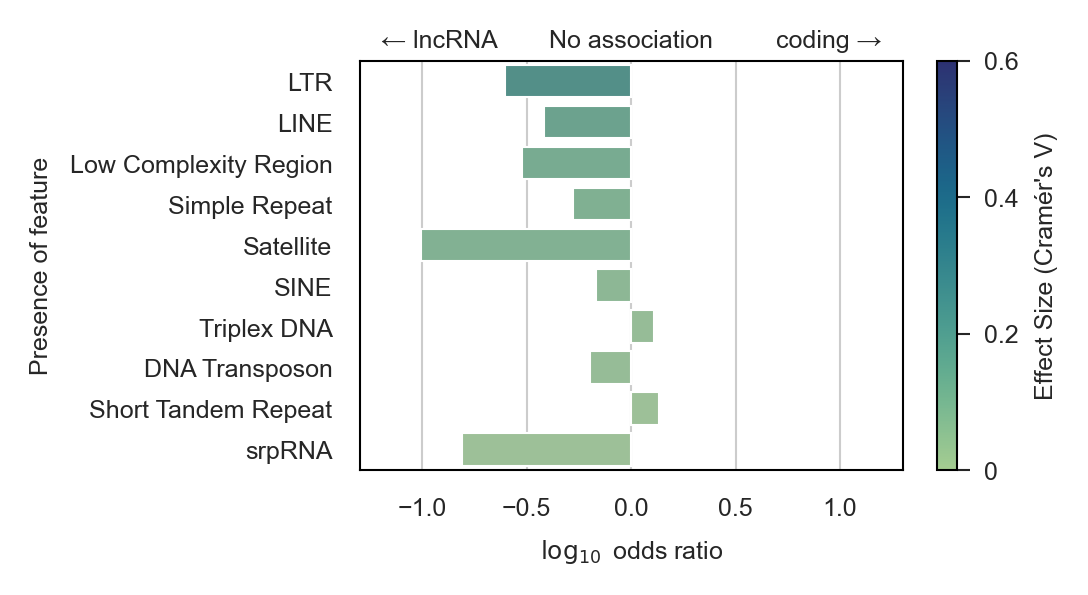

In [ ]:
# Select top 10 categorical features by Cramér's V
top10 = chi2_df.sort_values('cramers_v', ascending=False).head(10).copy()
top10['label'] = top10.index.map(chi2_label_dict)
top10['label'] = top10['label'].fillna(top10.index.to_series())
top10["log10_odds_ratio"] = np.log10(top10["odds_ratio"].replace(0, np.nan))

# Colors
norm = plt.Normalize(0, 0.6)
cmap = sns.color_palette("crest", as_cmap=True)
#cmap = sns.color_palette('RdYlBu_r', as_cmap=True)
#cmap = plt.cm.Blues

fig_h_cm = 5
fig_w_cm = 9

# Plot
fig, ax = plt.subplots(figsize=(fig_w_cm / 2.54 , fig_h_cm/2.54), dpi=300)
bar = sns.barplot(x=top10['log10_odds_ratio'], y=top10.index[::-1], hue=top10['cramers_v'], palette=cmap, hue_norm=norm, ax=ax)

# Ticks and labels
y_pos = np.arange(len(top10))[::-1]  # highest rank at top
ax.set_yticks(y_pos)
ax.set_yticklabels(top10['label'][::-1])
ax.set_ylabel("Presence of feature")
#ax.set_xlabel(r'$\log_{10}$' + " odds ratio\n(direction and magnitude)")
ax.set_xlabel(r'$\log_{10}$' + " odds ratio")
#ax.set_title("Top 10 Categorical Features with association to\ncoding vs lncRNA in low entropy group", pad=15)
ax.set_xlim(-1.3, 1.3)

# Add annotation on top of graph with direction
# Right is pc, left is lncRNA, 0 shows no association
ax.text(1.2, 1.02, 'coding →', ha='right', va='bottom', transform=ax.get_xaxis_transform())
ax.text(-1.2, 1.02, '← lncRNA', ha='left', va='bottom', transform=ax.get_xaxis_transform())
ax.text(0, 1.02, 'No association', ha='center', va='bottom', transform=ax.get_xaxis_transform())

# Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
ax.get_legend().remove()
cbar = ax.figure.colorbar(sm, ax=ax)
cbar.set_label("Effect Size (Cramér's V)")
cbar.set_ticks([0, 0.2, 0.4, 0.6])
#cbar.set_ticklabels(['0', '0.2 (mild)', '0.4 (medium)', '0.6 (strong)'])
cbar.set_ticklabels(['0', '0.2', '0.4', '0.6'])


plt.tight_layout()
plt.show()

#### Frequencies

In [ ]:
# Calculate frequencies for categorical features by entropy group
feature_frequencies = []

for feature in top10.index:
    # Low entropy group
    lncRNA = categorical_features.loc[grp1, feature]
    
    # High entropy group
    coding = categorical_features.loc[grp2, feature]
    
    feature_frequencies.append({
        'feature': feature,
        'lncRNA_freq': lncRNA.sum() / len(lncRNA) * 100,
        'coding_freq': coding.sum() / len(coding) * 100,
        'lncRNA_n': len(grp1),
        'coding_n': len(grp2)
    })
    
    freq_df = pd.DataFrame(feature_frequencies).set_index('feature')

# Add labels
freq_df['label'] = freq_df.index.map(chi2_label_dict)

# Reorder by top10 order (highest Cramér's V first)
freq_df = freq_df.loc[top10.index]

print("Feature frequencies by class and entropy group:")
print(freq_df[['label', 'lncRNA_freq', 'coding_freq']].round(1))


Feature frequencies by class and entropy group:
                                         label  lncRNA_freq  coding_freq
feature                                                                 
te_has_ltr                                 LTR         26.3          8.1
te_has_line                               LINE         21.9          9.7
lctr_has_low_complexity  Low Complexity Region          7.9          2.5
lctr_has_simple_repeat           Simple Repeat         20.2         11.8
lctr_has_satellite                   Satellite          2.0          0.2
te_has_sine                               SINE         29.9         22.5
tri_present                        Triplex DNA         62.0         67.7
te_has_dna                      DNA Transposon          8.6          5.7
str_present                Short Tandem Repeat         92.4         94.3
te_has_srprna                           srpRNA          0.4          0.1


In [ ]:
freq_df

,lncRNA_freq,coding_freq,lncRNA_n,coding_n,label
feature,,,,,
te_has_ltr,26.271186,8.140304,708,3022,LTR
te_has_line,21.892655,9.728657,708,3022,LINE
lctr_has_low_complexity,7.909605,2.514891,708,3022,Low Complexity Region
lctr_has_simple_repeat,20.197740,11.780278,708,3022,Simple Repeat
lctr_has_satellite,1.977401,0.198544,708,3022,Satellite
te_has_sine,29.943503,22.501655,708,3022,SINE
tri_present,62.005650,67.703508,708,3022,Triplex DNA
te_has_dna,8.615819,5.658504,708,3022,DNA Transposon
str_present,92.372881,94.275314,708,3022,Short Tandem Repeat


In [ ]:
freq_df

,lncRNA_freq,coding_freq,lncRNA_n,coding_n,label
feature,,,,,
te_has_ltr,26.271186,8.140304,708,3022,LTR
te_has_line,21.892655,9.728657,708,3022,LINE
lctr_has_low_complexity,7.909605,2.514891,708,3022,Low Complexity Region
lctr_has_simple_repeat,20.197740,11.780278,708,3022,Simple Repeat
lctr_has_satellite,1.977401,0.198544,708,3022,Satellite
te_has_sine,29.943503,22.501655,708,3022,SINE
tri_present,62.005650,67.703508,708,3022,Triplex DNA
te_has_dna,8.615819,5.658504,708,3022,DNA Transposon
str_present,92.372881,94.275314,708,3022,Short Tandem Repeat


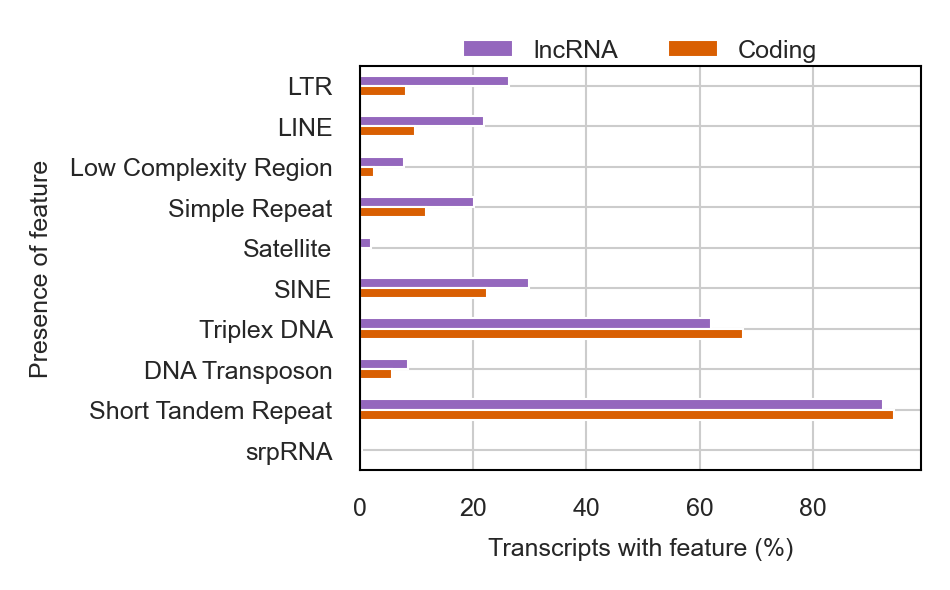

In [ ]:
fig_h_cm = 5
fig_w_cm = 8

freq_df = freq_df.rename(columns={'lncRNA_freq': 'lncRNA', 'coding_freq': 'Coding'})

fig, ax = plt.subplots(figsize=(fig_w_cm/2.54, fig_h_cm/2.54), dpi=300)
freq_df.plot.barh(x='label', y=['lncRNA', 'Coding'], ax=ax, color=['#9467bd', '#d95f02'])

ax.invert_yaxis()  # Highest rank at top

ax.set_xlabel("Transcripts with feature (%)")
ax.set_ylabel("Presence of feature")

ax.legend(title="", loc='upper center', bbox_to_anchor=(0.5, 1.12), ncol=2, frameon=False)
plt.tight_layout()
plt.show()

### 6.2 Continuous variables

In [ ]:
mannu_to_plot = combined_df.loc[(combined_df["test"] == 'Mann-Whitney U'), mann_tidy_columns + ["abs_vda"]].sort_values('abs_vda', ascending=False).head(10)
mannu_to_plot.index.tolist()

['ORF_T0_length_lncDC',
 'ORF_T0_MW_lncDC',
 'ORF_T2_length_lncDC',
 'ORF_T2_MW_lncDC',
 'Hexamer_score_ORF_T0_lncDC',
 'kmerScore_12mer_feelnc',
 'RCB_T0_lncDC',
 'Signal.Peak_lncfinder',
 'MFE_lncfinder',
 'Signal.Max_lncfinder']

In [ ]:
mannu_dict = {
'ORF_T1_length_lncDC': 'ORF length (type 1)',
 'RNA_size_feelnc': 'Transcript length',
 'Signal.Min_lncfinder': 'Minimum frame signal',
 'SS.pct.dist_lncfinder': 'Log. distance to coding SS',
 'Signal.Q1_lncfinder': 'Q1 of frame signal',
 'Signal.Q2_lncfinder': 'Q2 of frame signal',
 'SS.lnc.dist_lncfinder': 'Log. distance to lncRNA SS',
 'MFE_lncfinder': 'Minimum free energy',
 'Signal.Max_lncfinder': 'Maximum frame signal',
 'Dot_pct.dist_lncfinder': 'Distance to coding SS (dot format)',
 'ORF_T0_MW_lncDC': 'ORF Mol. Weight (type 1)',
 'ORF_T0_length_lncDC': 'ORF length (type 0)',
 'ORF_l_cpat': 'ORF length (CPAT)',
 'ORF.Max.Len_lncfinder': 'Max. ORF length',
 'Seq.pct.Dist_lncfinder': 'Log. distance to coding seqs.',
 'Seq.lnc.Dist_lncfinder': 'Log. distance to lncRNA seqs.',
 'Fickett_l_cpat': 'Fickett score (CPAT)',
 'Hexamer_l_cpat': 'Hexamer score (CPAT)',
 'Signal.Peak_lncfinder': 'Peak frame signal',
 'RCB_T0_lncDC': 'ORF relative codon bias (type 0)',
 'global_gaps_max': 'Max gap length between rep. elements',
 'SS.Dist.Ratio_lncfinder': 'Ratio of Distance coding vs lncRNA SS',
 'total_nonb_count': 'Total non-B DNA motifs',
 'ORF_T0_coverage_lncDC': 'ORF coverage (type 0)',
 'RCB_T1_lncDC': 'ORF relative codon bias (type 1)',
 'ORF_T2_MW_lncDC': 'ORF Mol. Weight (type 2)',
 'Hexamer_score_ORF_T0_lncDC': 'Hexamer score (ORF type 0)',
}

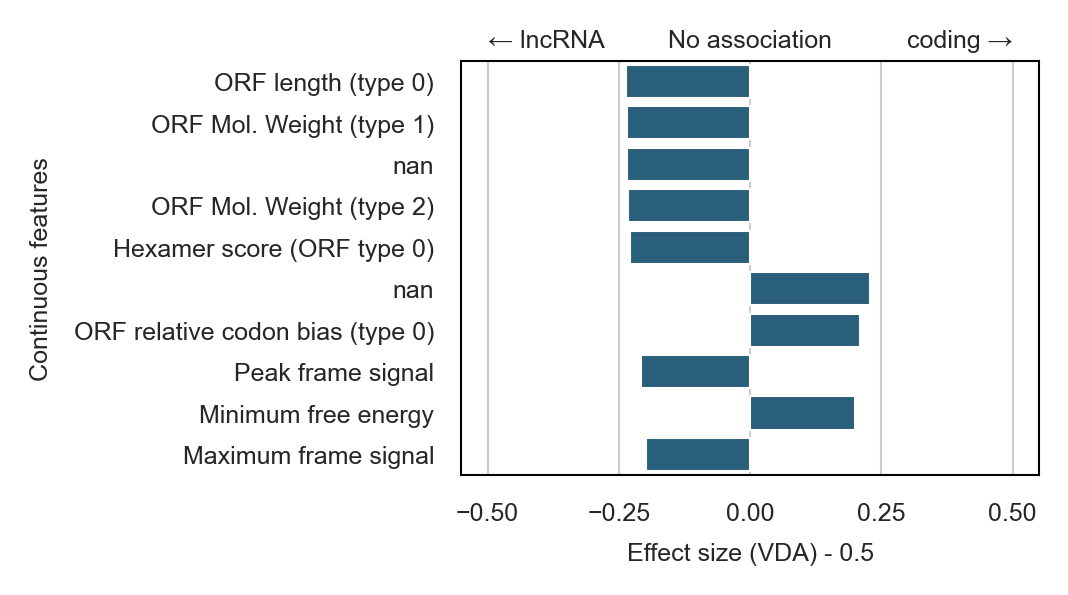

In [ ]:
# Select top 10 categorical features by Cramér's V
top10 = mannu_to_plot
top10["vda_to_plot"] = top10["vda"] - 0.5  # Center around 0 for better color mapping

top10['label'] = top10.index.map(mannu_dict)
#top10['label'] = top10.index

# Colors
norm = plt.Normalize(0, 0.6)
cmap = sns.color_palette("crest")
#cmap = sns.color_palette('RdYlBu_r', as_cmap=True)
#cmap = plt.cm.Blues

fig_h_cm = 5
fig_w_cm = 9

# Plot
fig, ax = plt.subplots(figsize=(fig_w_cm / 2.54 , fig_h_cm/2.54), dpi=300)
bar = sns.barplot(x=top10['vda_to_plot'], y=top10.index[::-1], ax=ax, color=sns.color_palette("crest")[-2])

y_pos = np.arange(len(top10))[::-1]  # highest rank at top
ax.set_yticks(y_pos)
ax.set_yticklabels(top10['label'][::-1])
ax.set_ylabel("Continuous features", labelpad=5)
ax.set_xlabel("Effect size (VDA) - 0.5")
#ax.set_title("Top 10 Categorical Features with association to\ncoding vs lncRNA in low entropy group", pad=30)
ax.set_xlim(-0.55, 0.55)
ax.set_xticks([-0.5, -0.25, 0, 0.25, 0.5])
#ax.set_xticklabels(['0.0', '0.25', '0.5', '0.75', '1.0'])

#Add annotation on top of graph with direction
#Right is pc, left is lncRNA, 0 shows no association
ax.text(0.5, 1.02, 'coding →', ha='right', va='bottom', transform=ax.get_xaxis_transform())
ax.text(-0.5, 1.02, '← lncRNA', ha='left', va='bottom', transform=ax.get_xaxis_transform())
ax.text(0, 1.02, 'No association', ha='center', va='bottom', transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.show()

## 6.3 Selected continuous variables after clustering

In [ ]:
cluster_df = pd.read_csv("/mnt/cbib/LNClassifier/paper/results/gencode.v47.common.cdhit.cv/features/clustering/feature_clusters_at_distances.csv", index_col=0)
cluster_df

,cluster_0.05,cluster_0.10,cluster_0.15,cluster_0.20,cluster_0.25,cluster_0.30,cluster_0.35,cluster_0.40,cluster_0.45,cluster_0.50,cluster_0.55,cluster_0.60,cluster_0.65,cluster_0.70,cluster_0.75,cluster_0.80,cluster_0.85,cluster_0.90,cluster_0.95,cluster_1.00,cluster_1.05,cluster_1.10,cluster_1.15,cluster_1.20,cluster_1.25,cluster_1.30,cluster_1.35,cluster_1.40,cluster_1.45
feature,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AAA_plncpro,220,188,168,152,136,123,109,102,93,85,80,74,71,70,68,63,59,55,51,46,42,38,35,33,32,30,27,24,18
AAC_plncpro,196,164,146,131,117,105,95,90,82,78,73,67,64,63,62,58,54,51,48,44,40,36,33,31,30,28,26,23,17
AAG_plncpro,193,161,143,128,115,103,94,89,81,77,72,66,63,62,61,57,53,50,48,44,40,36,33,31,30,28,26,23,17
AAT_plncpro,218,186,167,151,136,123,109,102,93,85,80,74,71,70,68,63,59,55,51,46,42,38,35,33,32,30,27,24,18
ACA_plncpro,198,166,148,133,119,107,97,91,83,78,73,67,64,63,62,58,54,51,48,44,40,36,33,31,30,28,26,23,17
ACC_plncpro,202,170,152,137,123,111,101,95,86,80,75,69,66,65,64,60,56,53,50,45,41,37,34,32,31,29,27,24,18
ACG_plncpro,272,236,213,193,176,163,143,130,120,106,97,90,84,83,79,73,69,65,60,54,49,44,40,37,36,33,30,27,21
ACT_plncpro,255,221,201,182,166,153,134,122,112,100,92,85,81,80,77,71,67,63,58,52,47,42,38,35,34,32,29,26,20
AGA_plncpro,195,163,145,130,116,104,94,89,81,77,72,66,63,62,61,57,53,50,48,44,40,36,33,31,30,28,26,23,17


In [ ]:
clustered_mannu = combined_df.loc[(combined_df["test"] == 'Mann-Whitney U'), mann_tidy_columns + ["abs_vda"]].sort_values('abs_vda', ascending=False)
clustered_mannu = clustered_mannu.merge(cluster_df["cluster_0.25"], left_index=True, right_index=True, how='left')

# Given the importance of sequence length in our analyses, I want to cherry pick it here
# Let's do it in a quick and dirty way: remove other features in its group
length_cluster = clustered_mannu[clustered_mannu.index == 'RNA_size_feelnc']['cluster_0.25'].values
if length_cluster.size > 0:
    print(f"RNA_size_feelnc is in cluster {length_cluster}")

# Remove all features in the same cluster except RNA_size_feelnc
if length_cluster is not None:
    features_to_remove = clustered_mannu[clustered_mannu['cluster_0.25'] == length_cluster[0]].index.difference(['RNA_size_feelnc'])
    print(f"Removing features in the same cluster as RNA_size_feelnc: {features_to_remove.tolist()}")
    clustered_mannu = clustered_mannu.drop(index=features_to_remove)
else:
    print("RNA_size_feelnc not found in any cluster, no features removed")

# Re-sort by VDA effect size
clustered_mannu = clustered_mannu.sort_values('abs_vda', ascending=False).groupby('cluster_0.25').head(1)
clustered_mannu

RNA_size_feelnc is in cluster [60.]
Removing features in the same cluster as RNA_size_feelnc: ['Dot_lnc.dist_lncfinder', 'Dot_pct.dist_lncfinder', 'MFE_lncfinder', 'ORF_T1_length_lncDC', 'SS.lnc.dist_lncfinder', 'SS.pct.dist_lncfinder', 'Signal.Max_lncfinder', 'Signal.Min_lncfinder', 'Signal.Q1_lncfinder', 'Signal.Q2_lncfinder']


,adjusted_p_value,rank_perc,test,vda,interpretation,significant,abs_vda,cluster_0.25
ORF_T0_length_lncDC,3.854129e-83,100.000000,Mann-Whitney U,0.263375,0.263 probability of being higher in lncRNA group,True,0.236625,56.0
ORF_T2_length_lncDC,4.123062e-82,99.533800,Mann-Whitney U,0.265506,0.266 probability of being higher in lncRNA group,True,0.234494,55.0
Hexamer_score_ORF_T0_lncDC,5.384964e-78,99.067599,Mann-Whitney U,0.271755,0.272 probability of being higher in lncRNA group,True,0.228245,168.0
kmerScore_12mer_feelnc,6.213840e-78,98.834499,Mann-Whitney U,0.728038,0.728 probability of being higher in lncRNA group,True,0.228038,169.0
Signal.Peak_lncfinder,4.279326e-65,98.368298,Mann-Whitney U,0.291787,0.292 probability of being higher in lncRNA group,True,0.208213,54.0
ir_gaps_mean_pct,1.913188e-57,97.668998,Mann-Whitney U,0.695342,0.695 probability of being higher in lncRNA group,True,0.195342,59.0
Hexamer_score_ORF_T2_lncDC,1.173434e-52,96.270396,Mann-Whitney U,0.313467,0.313 probability of being higher in lncRNA group,True,0.186533,173.0
RNA_size_feelnc,3.620780e-51,95.221445,Mann-Whitney U,0.316323,0.316 probability of being higher in lncRNA group,True,0.183677,60.0
str_mean_length_pct,3.711882e-50,94.871795,Mann-Whitney U,0.681783,0.682 probability of being higher in lncRNA group,True,0.181783,58.0
global_rm_total_length,1.296782e-54,94.172494,Mann-Whitney U,0.322526,0.323 probability of being higher in lncRNA group,True,0.177474,106.0


In [ ]:
mannu_dict = {
'ORF_T1_length_lncDC': 'ORF length (type 1)',
 'RNA_size_feelnc': 'Transcript length',
 'Signal.Min_lncfinder': 'Minimum frame signal',
 'SS.pct.dist_lncfinder': 'Log. distance to coding SS',
 'Signal.Q1_lncfinder': 'Q1 of frame signal',
 'Signal.Q2_lncfinder': 'Q2 of frame signal',
 'SS.lnc.dist_lncfinder': 'Log. distance to lncRNA SS',
 'MFE_lncfinder': 'Minimum free energy',
 'Signal.Max_lncfinder': 'Maximum frame signal',
 'Dot_pct.dist_lncfinder': 'Distance to coding SS (dot format)',
 'ORF_T0_MW_lncDC': 'ORF Mol. Weight (type 1)',
 'ORF_T0_length_lncDC': 'ORF length (type 0)',
 'ORF_l_cpat': 'ORF length (CPAT)',
 'ORF.Max.Len_lncfinder': 'Max. ORF length',
 'Seq.pct.Dist_lncfinder': 'Log. distance to coding seqs.',
 'Seq.lnc.Dist_lncfinder': 'Log. distance to lncRNA seqs.',
 'Fickett_l_cpat': 'Fickett score (CPAT)',
 'Hexamer_l_cpat': 'Hexamer score (CPAT)',
 'Signal.Peak_lncfinder': 'Peak frame signal',
 'RCB_T0_lncDC': 'ORF relative codon bias (type 0)',
 'global_gaps_max': 'Max gap length between rep. elements',
 'SS.Dist.Ratio_lncfinder': 'Distance ratio (lncRNA SS/coding SS)',
 'total_nonb_count': 'Total non-B DNA motifs',
 'ORF_T0_coverage_lncDC': 'ORF coverage (type 0)',
 'RCB_T1_lncDC': 'ORF relative codon bias (type 1)',
 'ORF_T2_MW_lncDC': 'ORF Mol. Weight (type 2)',
 'Hexamer_score_ORF_T0_lncDC': 'Hexamer score (ORF type 0)',
 'Hexamer_score_ORF_T2_lncDC': 'Hexamer score (ORF type 2)',
 'kmerScore_12mer_feelnc': '12-mer k-mer score',
 'ORF.Max.Cov_lncfinder': 'Max. ORF coverage',
 'ORF_T2_length_lncDC': 'ORF length (type 2)',
 'ir_gaps_mean_pct': 'Mean gap cvg. between IRs',
 'str_mean_length_pct': 'Mean coverage of STRs',
 'ir_max_length_pct': 'Max coverage of an IR',
 'str_max_length_pct': 'Max coverage of a STR',
 'global_rm_total_length': 'Total length covered by repeats',
}

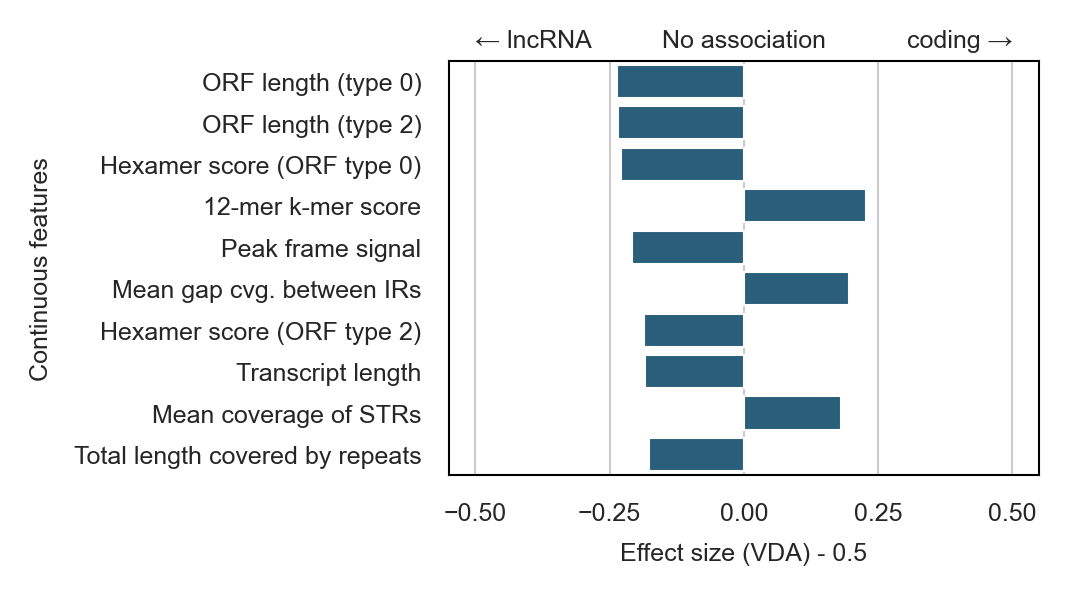

In [ ]:
# Select top 10 categorical features by Cramér's V
top10 = clustered_mannu.head(10)
top10["vda_to_plot"] = top10["vda"] - 0.5  # Center around 0 for better color mapping

top10['label'] = top10.index.map(mannu_dict)
top10['label'] = top10['label'].fillna(top10.index.to_series())

# Colors
norm = plt.Normalize(0, 0.6)
cmap = sns.color_palette("crest")
#cmap = sns.color_palette('RdYlBu_r', as_cmap=True)
#cmap = plt.cm.Blues

fig_h_cm = 5
fig_w_cm = 9

# Plot
fig, ax = plt.subplots(figsize=(fig_w_cm / 2.54 , fig_h_cm/2.54), dpi=300)
bar = sns.barplot(x=top10['vda_to_plot'], y=top10.index[::-1], ax=ax, color=sns.color_palette("crest")[-2])

y_pos = np.arange(len(top10))[::-1]  # highest rank at top
ax.set_yticks(y_pos)
ax.set_yticklabels(top10['label'][::-1])
ax.set_ylabel("Continuous features", labelpad=5)
ax.set_xlabel("Effect size (VDA) - 0.5")
#ax.set_title("Top 10 Categorical Features with association to\ncoding vs lncRNA in low entropy group", pad=30)
ax.set_xlim(-0.55, 0.55)
ax.set_xticks([-0.5, -0.25, 0, 0.25, 0.5])
#ax.set_xticklabels(['0.0', '0.25', '0.5', '0.75', '1.0'])

#Add annotation on top of graph with direction
#Right is pc, left is lncRNA, 0 shows no association
ax.text(0.5, 1.02, 'coding →', ha='right', va='bottom', transform=ax.get_xaxis_transform())
ax.text(-0.5, 1.02, '← lncRNA', ha='left', va='bottom', transform=ax.get_xaxis_transform())
ax.text(0, 1.02, 'No association', ha='center', va='bottom', transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.show()

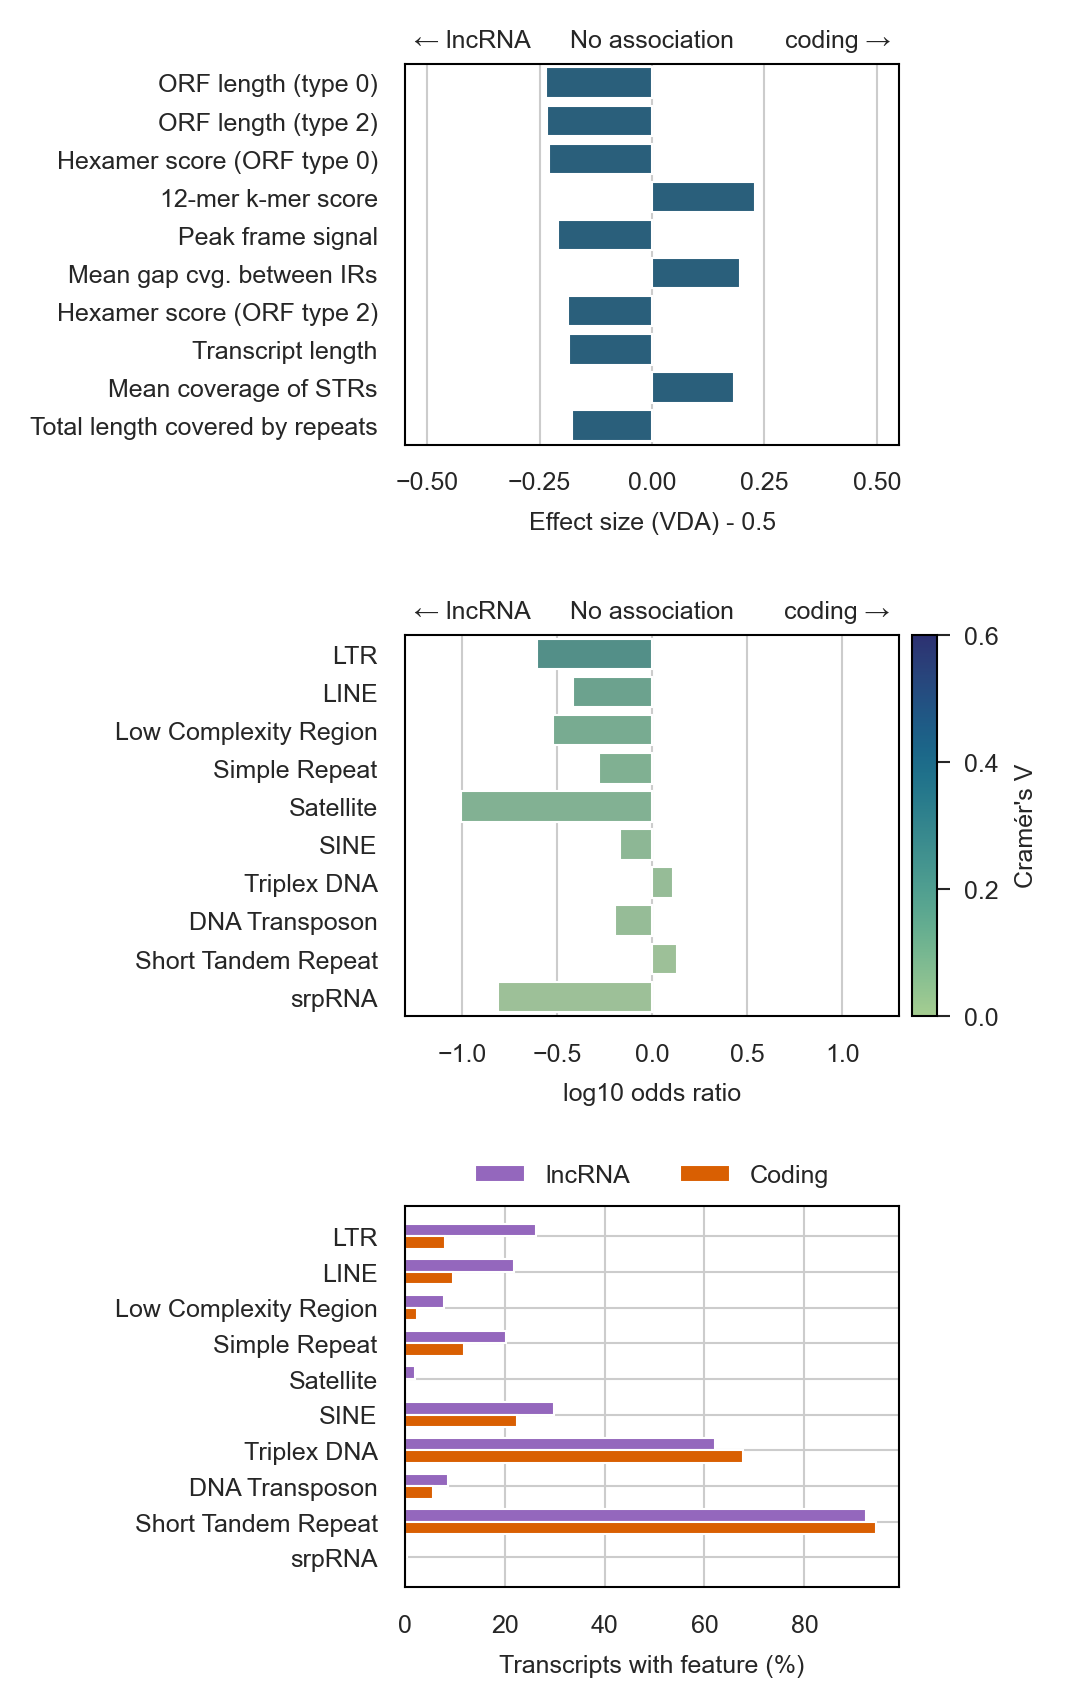

In [ ]:
import matplotlib.gridspec as gridspec

# Create combined grid plot with three graphs vertically aligned
# Use GridSpec to have explicit control over subplot widths
fig = plt.figure(figsize=(8.5 / 2.54, 15 / 2.54), dpi=300)
gs = gridspec.GridSpec(3, 2, figure=fig, width_ratios=[1, 0.05], wspace=0.05, hspace=0.5)

# Create main axes - all in the first column to ensure same width
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[2, 0])

# Create colorbar axis only for middle plot
cax = fig.add_subplot(gs[1, 1])

# === Plot 1: Continuous variables after clustering ===
top10_cont = clustered_mannu.head(10)
top10_cont["vda_to_plot"] = top10_cont["vda"] - 0.5
top10_cont['label'] = top10_cont.index.map(mannu_dict)
top10_cont['label'] = top10_cont['label'].fillna(top10_cont.index.to_series())

sns.barplot(x=top10_cont['vda_to_plot'], y=top10_cont.index[::-1], ax=ax0, color=sns.color_palette("crest")[-2])
ax0.set_yticks(np.arange(len(top10_cont))[::-1])
ax0.set_yticklabels(top10_cont['label'][::-1], fontsize=6)
ax0.set_ylabel("", fontsize=6)
ax0.set_xlabel("Effect size (VDA) - 0.5", fontsize=6)
ax0.set_xlim(-0.55, 0.55)
ax0.set_xticks([-0.5, -0.25, 0, 0.25, 0.5])
ax0.text(0.53, 1.03, 'coding →', ha='right', va='bottom', transform=ax0.get_xaxis_transform(), fontsize=6)
ax0.text(-0.53, 1.03, '← lncRNA', ha='left', va='bottom', transform=ax0.get_xaxis_transform(), fontsize=6)
ax0.text(0, 1.03, 'No association', ha='center', va='bottom', transform=ax0.get_xaxis_transform(), fontsize=6)

# === Plot 2: Categorical variables ===
top10_cat = chi2_df.sort_values('cramers_v', ascending=False).head(10).copy()
top10_cat['label'] = top10_cat.index.map(chi2_label_dict)
top10_cat["log10_odds_ratio"] = np.log10(top10_cat["odds_ratio"].replace(0, np.nan))

norm_cat = plt.Normalize(0, 0.6)
cmap_cat = sns.color_palette("crest", as_cmap=True)

sns.barplot(x=top10_cat['log10_odds_ratio'], y=top10_cat.index[::-1], hue=top10_cat['cramers_v'], 
            palette=cmap_cat, hue_norm=norm_cat, ax=ax1)

ax1.set_yticks(np.arange(len(top10_cat))[::-1])
ax1.set_yticklabels(top10_cat['label'][::-1], fontsize=6)
ax1.set_ylabel("", fontsize=6)
ax1.set_xlabel("log10 odds ratio", fontsize=6)
ax1.set_xlim(-1.3, 1.3)
ax1.text(1.25, 1.03, 'coding →', ha='right', va='bottom', transform=ax1.get_xaxis_transform(), fontsize=6)
ax1.text(-1.25, 1.03, '← lncRNA', ha='left', va='bottom', transform=ax1.get_xaxis_transform(), fontsize=6)
ax1.text(0, 1.03, 'No association', ha='center', va='bottom', transform=ax1.get_xaxis_transform(), fontsize=6)
ax1.get_legend().remove()

# Colorbar for categorical plot in separate axis
sm = plt.cm.ScalarMappable(cmap=cmap_cat, norm=norm_cat)
cbar1 = plt.colorbar(sm, cax=cax)
cbar1.set_label("Cramér's V", fontsize=6)
cbar1.set_ticks([0, 0.2, 0.4, 0.6])
cbar1.ax.tick_params(labelsize=6)

# === Plot 3: Proportions ===
freq_df_plot = freq_df[['label', 'lncRNA', 'Coding']].loc[top10_cat.index]

x_pos = np.arange(len(freq_df_plot))
width = 0.35

ax2.barh(x_pos - width/2, freq_df_plot['lncRNA'], width, label='lncRNA', color='#9467bd')
ax2.barh(x_pos + width/2, freq_df_plot['Coding'], width, label='Coding', color='#d95f02')

ax2.set_yticks(x_pos)
ax2.set_yticklabels(freq_df_plot['label'], fontsize=6)
ax2.invert_yaxis()
ax2.set_xlabel("Transcripts with feature (%)", fontsize=6)
ax2.set_ylabel("", fontsize=6)
ax2.legend(title="", loc='upper center', bbox_to_anchor=(0.5, 1.17), ncol=2, frameon=False, fontsize=6)

# Save
fig.subplots_adjust(left=0.35, right=0.88, top=0.93, bottom=0.07, hspace=0.4)
plt.savefig(os.path.join(FIGURE_DIR, "high_entropy_pc_v_lnc_statistical_tests_results.pdf"),
            dpi=300,
            format='pdf',
            bbox_inches='tight')
plt.show()
